# Get the dataset

In [3]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tsepomayaba
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 1.17GB/s]

# Libraries

In [4]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Enable the GPU

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


# Import the dataset

In [6]:
df = pd.read_csv('/content/rice-type-classification/riceClassification.csv')
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


# Data preprocessing
This is done in order to get a better accuracy score after training the model

In [7]:
def DataPreprocessing(df: pd.DataFrame):
  """
  This function is responsible for performing some basic preprocessing.

  Parameters:
    - df: Raw dataset

  Returns
    - df_copy: Preprocessed dataset
  """
  if df is not None:
    df_copy = df.copy()

    # Check the shape of the dataset
    print('Shape of processed data: ', df_copy.shape)
    print('-'*20)
    print()

    # Remove missing rows
    df_copy.dropna(inplace=True)

    # Remove unecessary columns
    df_copy.drop(['id'], axis=1, inplace=True)

    # Check the distribution of the target variable
    print(df_copy['Class'].value_counts())

    # normalize the dataset
    for column in df_copy.columns:
      df_copy[column] = df_copy[column] / df_copy[column].abs().max()

    return df_copy

preprocessed_df = DataPreprocessing(df)
preprocessed_df.head()

Shape of processed data:  (18185, 12)
--------------------

Class
1    9985
0    8200
Name: count, dtype: int64


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [8]:
# Separate X and y variables
X = np.array(preprocessed_df.iloc[:, :-1])
y = np.array(preprocessed_df.iloc[:, -1])

# Data partitioning
We will split the data into 80% Training set and 20% Testing set.
The Training set will be used to train the model. The Testing set will be used to evaluate the model's ability to generalize on unseen data.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# Evaluation set
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)

# Model development
We will be training a ... model to classify different types of rice.

In [31]:
# Make the datasets ready to be used by the model
class dataset(Dataset):
  def __init__(self, X, y):
    """
    This function is the class constructor.

    Parameters:
      - X: inputs
      - y: outputs
    """

    # Convert the input to tensor
    self.X = torch.tensor(X, dtype = torch.float32).to(device)

    # Convert the output to tensor
    self.y = torch.tensor(y, dtype = torch.float32).to(device)

  def __len__(self):
    """
    This function is responsible for returning the length of the inputs (X)
    """
    return len(self.X)

  def __getitem__(self, idx):
    """
    This function gets an items by its index.

    Parameters:
      - idx: index of the item
    """
    return self.X[idx], self.y[idx]

train_dataset = dataset(X_train, y_train)
test_dataset = dataset(X_test, y_test)
validation_dataset = dataset(X_val, y_val)

In [32]:
# Create data loader for each dataset
train_dataLoader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle = True
)

test_dataLoader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle = True
)

validation_dataLoader = DataLoader(
    validation_dataset,
    batch_size=8,
    shuffle = True
)

In [ ]:
HIDDEN_NEURONS = 10

class Model(nn.Module):
  def __init__(self):
    super(Model, self).__init__()
    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()


  def forward(self, X):
    """
    This function is responsible for defining how the data will flow in the model

    Conceptual flow:
      input layer -> linear -> sigmoid (loss function)

    """

    x = self.input_layer(X)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x


# Initialize the model and move to device
model = Model().to(device)

In [39]:
# Create the summary
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [40]:
# Create the loss function
criterion = nn.BCELoss()

# Create the optimizer function
optimizer = Adam(model.parameters(), lr = 1e-3)

# Model training
In this section, we will begin to train the model.

In [46]:
# Define the number of epochs
epochs = 10

training_loss = []
validation_loss = []

training_accuracy = []
validation_accuracy = []

for epoch in range(epochs):
  total_train_acc = 0
  total_train_loss = 0
  total_val_loss = 0
  total_val_acc = 0

  for data in train_dataLoader:
    # Get the inputs and outputs
    inputs, labels = data

    # Generate predictions
    pred = model(inputs).squeeze(1)

    # Calculate the loss for each batch
    batch_loss = criterion(pred, labels)

    # Increment the training loss
    total_train_loss += batch_loss.item()

    # Count the total number of labels predicted correctly
    accuracy = ((pred).round() == labels).sum().item()

    # Increment the training accuracy
    total_train_acc += accuracy

    # Backward propagation
    batch_loss.backward()

    optimizer.step()

    # Restart optimizer
    optimizer.zero_grad()

  # Model evaluation
  with torch.no_grad():
    for data in validation_dataLoader:
      inputs, labels = data

      # Generate the predictions
      pred = model(inputs).squeeze(1)

      # Calculate the loss
      batch_loss = criterion(pred, labels)

      total_val_loss += batch_loss.item()

      accuracy = ((pred).round() == labels).sum().item()

      total_val_acc += accuracy

  train_loss = round(total_train_loss/1000, 4)
  val_loss = round(total_val_loss/1000, 4)
  training_loss.append(train_loss)
  validation_loss.append(val_loss)

  # Calculation: Number of labels predicted correctly / length of the labels e.g 6 / 10 = 0.6 * 100 = 60%
  train_acc = round(total_train_acc/train_dataset.__len__() * 100, 4)
  val_acc = round(total_val_acc/validation_dataset.__len__() * 100, 4)
  training_accuracy.append(train_acc)
  validation_accuracy.append(val_acc)

  print(f'Epoch no. {epoch+1} | Train loss: {train_loss} | Train accuracy: {train_acc} | Validation loss: {val_loss} | Validation accuracy: {val_acc}')
  print('='*100)


Epoch no. 1 | Train loss: 0.1309 | Train accuracy: 98.4131 | Validation loss: 0.0176 | Validation accuracy: 98.9003
Epoch no. 2 | Train loss: 0.0856 | Train accuracy: 98.5466 | Validation loss: 0.0136 | Validation accuracy: 98.937
Epoch no. 3 | Train loss: 0.0754 | Train accuracy: 98.4916 | Validation loss: 0.0124 | Validation accuracy: 98.937
Epoch no. 4 | Train loss: 0.0716 | Train accuracy: 98.5231 | Validation loss: 0.0123 | Validation accuracy: 98.7903
Epoch no. 5 | Train loss: 0.0765 | Train accuracy: 98.5388 | Validation loss: 0.0121 | Validation accuracy: 98.8636
Epoch no. 6 | Train loss: 0.07 | Train accuracy: 98.4602 | Validation loss: 0.014 | Validation accuracy: 98.7537
Epoch no. 7 | Train loss: 0.0686 | Train accuracy: 98.5938 | Validation loss: 0.0115 | Validation accuracy: 99.0103
Epoch no. 8 | Train loss: 0.068 | Train accuracy: 98.5623 | Validation loss: 0.0123 | Validation accuracy: 98.9003
Epoch no. 9 | Train loss: 0.0685 | Train accuracy: 98.5702 | Validation loss: 

# Model evaluation

In [49]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for data in test_dataLoader:
    inputs, labels = data

    # Generate the predictions
    pred = model(inputs).squeeze(1)

    # Calculate the loss
    batch_loss_test = criterion(pred, labels)

    # Increment the losss
    total_loss_test += batch_loss_test.item()

    # Calculate the accuracy
    accuracy = ((pred).round() == labels).sum().item()

    # Increment the accuracy
    total_acc_test += accuracy

test_acc = round(total_acc_test/test_dataset.__len__() * 100, 4)
print(f'Accuracy: {test_acc} %')

Accuracy: 98.4238 %


# Results
The model has achieved a ~98% accuracy score which is expected since this is a fairly small dataset and it is not complicated. However, with a large dataset, the model might need further fine tuning and hyperparameter optimization.

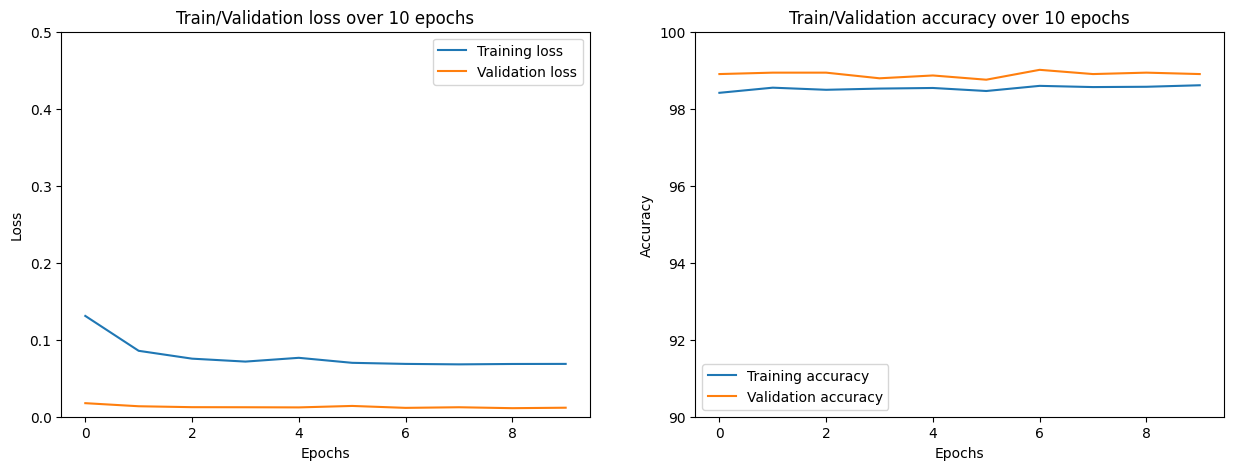

In [53]:
# Visualizations
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

# Plot for the loss
axs[0].plot(training_loss, label='Training loss')
axs[0].plot(validation_loss, label='Validation loss')
axs[0].set_title(f'Train/Validation loss over {epochs} epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,0.5])
axs[0].legend()

# Plot for the accuracy
axs[1].plot(training_accuracy, label='Training accuracy')
axs[1].plot(validation_accuracy, label='Validation accuracy')
axs[1].set_title(f'Train/Validation accuracy over {epochs} epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([90,100])
axs[1].legend()

plt.show()